In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import os
sns.set_theme()
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
cwd = os.getcwd()
print("Current working directory:", cwd)

# Change the working directory
#os.chdir('S:/OneDrive - University of Georgia/1 UGA/1 PhD/1 Spring24/Tobacco')
#os.chdir(r'/Users/sus/Library/CloudStorage/OneDrive-UniversityofGeorgia/1 UGA/1 PhD/1 Spring24/Tobacco')
os.chdir(r'/Users/sus/Library/CloudStorage/OneDrive-UniversityofGeorgia/1 UGA/1 PhD/Fall25/First_Chapter/madeData')

# Verify the change
print("New working directory:", os.getcwd())

Current working directory: /Users/sus/Library/CloudStorage/OneDrive-UniversityofGeorgia/1 UGA/1 PhD/1 Spring24/Tobacco/pythoncode/Susan/Tobacco/Final_data_preparation
New working directory: /Users/sus/Library/CloudStorage/OneDrive-UniversityofGeorgia/1 UGA/1 PhD/Fall25/First_chapter/madeData


In [3]:
# Loading the merged dataset
df = pd.read_csv(r'/Users/sus/Library/CloudStorage/OneDrive-UniversityofGeorgia/1 UGA/1 PhD/1 Spring24/Tobacco/madeData/heat_smoke_balanced_FINAL.csv')
df

,brand_n,region,W,qt,totrev,price,type
0,1,4,1,0.053,15.651,297.0,1.0
1,1,4,2,0.053,15.651,297.0,1.0
2,1,4,3,NaN,NaN,NaN,1.0
3,1,4,4,0.053,15.651,297.0,1.0
4,1,4,5,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...
3145033,1162,13,73,NaN,NaN,NaN,2.0
3145034,1162,13,74,NaN,NaN,NaN,2.0
3145035,1162,13,75,NaN,NaN,NaN,2.0
3145036,1162,13,76,NaN,NaN,NaN,2.0


Separate the dataset into REGIONAL and NATIONAL data

# REGIONAL DATA

In [4]:

# separating datasets with and without region 13(national total)
df1_not13 = df[df['region']!=13][[ 'brand_n', 'W', 'region', 'type', 'totrev','qt', 'price']] 
df1_not13

# managing the missing and zero sales data by removing the observations
df1_not13.dropna(subset=['totrev', 'qt'], how='any', inplace=True) ## I am dropping all the rows where totrev and qt is equal to na (these entities (J) donot exist)
df1_not13 = df1_not13[(df1_not13['totrev']!= 0) & (df1_not13['qt'] != 0)]
df1_not13

# Starting the data processing
## our entity is [region, week]. Our rows are unique for each entity and brand so we just find the pj and qj

df1_not13['pijt'] = df1_not13['totrev']/df1_not13['qt'] 
df1_not13['qijt'] = df1_not13['qt']


df1_not13['expt'] = df1_not13.groupby(['region', 'W', 'type'])['totrev'].transform('sum') ##sum of expenditure for all the products in that entity by type

df1_not13['sijt'] = df1_not13['totrev']/df1_not13['expt'] #budget share (will be used for tornqvist price index)

df1_not13

# Drop the base columns (pi0, etc.) so they don't duplicate when we merge later
df1_not13.drop(columns=['expt'], inplace=True)

# NATIONAL DATA

In [5]:

# separating datasets with and without region 13(national total)
df1_13 = df[df['region']==13][[ 'brand_n', 'W', 'region', 'type', 'totrev','qt', 'price']] 
df1_13



,brand_n,W,region,type,totrev,qt,price
183,1,1,13,1.0,15.651,0.053,297.0
184,1,2,13,1.0,15.651,0.053,297.0
185,1,3,13,1.0,NaN,NaN,NaN
186,1,4,13,1.0,15.651,0.053,297.0
187,1,5,13,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
3145033,1162,73,13,2.0,NaN,NaN,NaN
3145034,1162,74,13,2.0,NaN,NaN,NaN
3145035,1162,75,13,2.0,NaN,NaN,NaN
3145036,1162,76,13,2.0,NaN,NaN,NaN


Base Construction

In [6]:
# ==========================================
# 4. PREPARE BASE VECTOR (df1_13_nodup)
# ==========================================
# Use raw df1_13 (with filled NaNs) to get stable averages over time
df_base_calc = df1_13.copy()
df_base_calc['qt'] = df_base_calc['qt'].fillna(0)
df_base_calc['totrev'] = df_base_calc['totrev'].fillna(0)


df_base_calc

,brand_n,W,region,type,totrev,qt,price
183,1,1,13,1.0,15.651,0.053,297.0
184,1,2,13,1.0,15.651,0.053,297.0
185,1,3,13,1.0,0.000,0.000,NaN
186,1,4,13,1.0,15.651,0.053,297.0
187,1,5,13,1.0,0.000,0.000,NaN
...,...,...,...,...,...,...,...
3145033,1162,73,13,2.0,0.000,0.000,NaN
3145034,1162,74,13,2.0,0.000,0.000,NaN
3145035,1162,75,13,2.0,0.000,0.000,NaN
3145036,1162,76,13,2.0,0.000,0.000,NaN


In [7]:
# Calculate Mean Qty and Mean Revenue per Brand
df_base_calc['qi0'] = df_base_calc.groupby('brand_n')['qt'].transform('mean')
df_base_calc['totrev0'] = df_base_calc.groupby('brand_n')['totrev'].transform('mean')

# Calculate Base Price (pi0) = Unit Value
df_base_calc['pi0'] = np.where(df_base_calc['qi0'] > 0, 
                               df_base_calc['totrev0'] / df_base_calc['qi0'], 
                               np.nan)


df_base_calc

,brand_n,W,region,type,totrev,qt,price,qi0,totrev0,pi0
183,1,1,13,1.0,15.651,0.053,297.0,0.011240,3.340098,297.150219
184,1,2,13,1.0,15.651,0.053,297.0,0.011240,3.340098,297.150219
185,1,3,13,1.0,0.000,0.000,NaN,0.011240,3.340098,297.150219
186,1,4,13,1.0,15.651,0.053,297.0,0.011240,3.340098,297.150219
187,1,5,13,1.0,0.000,0.000,NaN,0.011240,3.340098,297.150219
...,...,...,...,...,...,...,...,...,...,...
3145033,1162,73,13,2.0,0.000,0.000,NaN,0.260667,666.298153,2556.131022
3145034,1162,74,13,2.0,0.000,0.000,NaN,0.260667,666.298153,2556.131022
3145035,1162,75,13,2.0,0.000,0.000,NaN,0.260667,666.298153,2556.131022
3145036,1162,76,13,2.0,0.000,0.000,NaN,0.260667,666.298153,2556.131022


In [8]:
# Calculate Base Share (s0) BY TYPE
# This ensures s0 is comparable to sijt (which is share of type expenditure)
df_base_calc['type_total_rev0'] = df_base_calc.groupby('type')['totrev0'].transform('sum')
df_base_calc['si0'] = df_base_calc['totrev0'] / df_base_calc['type_total_rev0']

df_base_calc
df1_13append = df_base_calc[['brand_n', 'region', 'W', 'type', 'totrev', 'qt', 'price', 'pi0', 'qi0', 'si0']].copy()


In [9]:
# Create Unique Base Vector
df1_13_nodup = df_base_calc[['brand_n', 'region', 'W', 'type', 'totrev', 'qt', 'price', 'pi0', 'qi0', 'si0']].drop_duplicates(subset=['brand_n'])
df1_13_nodup = df1_13_nodup.dropna(subset=['pi0'])
df1_13_nodup

,brand_n,region,W,type,totrev,qt,price,pi0,qi0,si0
183,1,13,1,1.0,15.651,0.053,297.0,297.150219,0.011240,3.957123e-10
2562,2,13,1,1.0,0.000,0.000,NaN,302.844509,0.009454,3.391837e-10
4941,3,13,1,1.0,0.000,0.000,NaN,3007.125786,0.001738,6.190816e-10
7320,4,13,1,1.0,0.000,0.000,NaN,445.294853,0.029727,1.568252e-09
9699,5,13,1,1.0,0.000,0.000,NaN,444.457979,0.011574,6.094328e-10
...,...,...,...,...,...,...,...,...,...,...
3135339,1158,13,78,2.0,0.000,0.000,NaN,2556.079284,0.350749,3.986943e-07
3137718,1159,13,78,2.0,0.000,0.000,NaN,426.000411,4.775749,9.047345e-07
3140097,1160,13,78,2.0,0.000,0.000,NaN,2555.904077,0.249060,2.830860e-07
3142476,1161,13,78,2.0,0.000,0.000,NaN,426.001822,3.479372,6.591465e-07


In [10]:
# ==========================================
# 2. PREPARE NATIONAL PANEL ROWS (df1_13app)
# ==========================================
# This creates the "Region 13" rows to append back to the main dataset
df1_13app = df1_13append.copy()

# Map base values to current values (This forces the Index = 1.0 for Region 13 rows)
df1_13app['pijt'] = df1_13app['pi0']
df1_13app['qijt'] = df1_13app['qi0']
df1_13app['sijt'] = df1_13app['si0']

# Add Placeholder Columns so it matches the structure of the main panel (df1_not13)
# You can change these values to whatever identifies "Region 13" in your study
#df1_13app['region'] = 13       
#df1_13app['W'] = 1             # Placeholder week

# Drop the base columns (pi0, etc.) so they don't duplicate when we merge later
df1_13app.drop(columns=['pi0', 'qi0', 'si0'], inplace=True)

In [11]:
# ==========================================
# 3. CONCATENATE & MERGE
# ==========================================
# A. Append the prepared Region 13 rows to the other regions
append_df1 = pd.concat([df1_not13, df1_13app], ignore_index=True)

append_df1

,brand_n,W,region,type,totrev,qt,price,pijt,qijt,sijt
0,1,1,4,1.0,15.651,0.053,297.0,295.301887,0.053000,4.893747e-06
1,1,2,4,1.0,15.651,0.053,297.0,295.301887,0.053000,4.651296e-06
2,1,4,4,1.0,15.651,0.053,297.0,295.301887,0.053000,4.582389e-06
3,1,6,4,1.0,23.579,0.079,297.0,298.468354,0.079000,7.185353e-06
4,1,8,4,1.0,15.720,0.053,297.0,296.603774,0.053000,4.805500e-06
...,...,...,...,...,...,...,...,...,...,...
1472157,1162,73,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07
1472158,1162,74,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07
1472159,1162,75,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07
1472160,1162,76,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07


In [12]:
# B. Merge the Base Vector (pi0, qi0, si0) onto EVERY row
# This ensures every region/week has access to the base prices for index calculation
df1_13_cleaner = df1_13_nodup.drop(columns=['region', 'W', 'type', 'totrev', 'qt', 'price'], inplace=True)
merged_df1 = pd.merge(append_df1, df1_13_nodup, on=['brand_n'], how='left')
merged_df1


,brand_n,W,region,type,totrev,qt,price,pijt,qijt,sijt,pi0,qi0,si0
0,1,1,4,1.0,15.651,0.053,297.0,295.301887,0.053000,4.893747e-06,297.150219,0.011240,3.957123e-10
1,1,2,4,1.0,15.651,0.053,297.0,295.301887,0.053000,4.651296e-06,297.150219,0.011240,3.957123e-10
2,1,4,4,1.0,15.651,0.053,297.0,295.301887,0.053000,4.582389e-06,297.150219,0.011240,3.957123e-10
3,1,6,4,1.0,23.579,0.079,297.0,298.468354,0.079000,7.185353e-06,297.150219,0.011240,3.957123e-10
4,1,8,4,1.0,15.720,0.053,297.0,296.603774,0.053000,4.805500e-06,297.150219,0.011240,3.957123e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472157,1162,73,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07,2556.131022,0.260667,2.963045e-07
1472158,1162,74,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07,2556.131022,0.260667,2.963045e-07
1472159,1162,75,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07,2556.131022,0.260667,2.963045e-07
1472160,1162,76,13,2.0,0.000,0.000,NaN,2556.131022,0.260667,2.963045e-07,2556.131022,0.260667,2.963045e-07


PRICE INDICES

In [13]:
# ==========================================
# 6. CALCULATE INDICES (Intersection Method)
# ==========================================
# Filter for Common Set (Intersection of Brand existing in Base and Brand existing in Region)
common_set = merged_df1.dropna(subset=['pi0', 'qi0', 'pijt']).copy()

# Laspeyres Components
common_set['L_num'] = common_set['pijt'] * common_set['qi0']
common_set['L_den'] = common_set['pi0'] * common_set['qi0']

# Paasche Components
common_set['P_num'] = common_set['pijt'] * common_set['qijt']
common_set['P_den'] = common_set['pi0'] * common_set['qijt']

# Tornqvist Components
common_set['ln_ratio'] = np.log(common_set['pijt'] / common_set['pi0'])
common_set['T_term'] = 0.5 * (common_set['sijt'] + common_set['si0']) * common_set['ln_ratio']

# Aggregate
indices = common_set.groupby(['region', 'W', 'type']).agg({
    'L_num': 'sum', 'L_den': 'sum',
    'P_num': 'sum', 'P_den': 'sum',
    'T_term': 'sum'
}).reset_index()

# Final Indices
indices['Laspeyres'] = indices['L_num'] / indices['L_den']
indices['Paasche'] = indices['P_num'] / indices['P_den']
indices['Fisher'] = np.sqrt(indices['Laspeyres'] * indices['Paasche'])
indices['Tornqvist'] = np.exp(indices['T_term'])

print(indices.head())

indices

indices = indices[[ 'region', 'W', 'type', 'Laspeyres', 'Paasche', 'Fisher', 'Tornqvist']].copy()



   region  W  type         L_num         L_den        P_num         P_den  \
0       1  1   1.0  4.183443e+07  4.355616e+07  2574839.806  2.681225e+06   
1       1  1   2.0  6.460718e+06  6.775824e+06   209494.044  2.196617e+05   
2       1  2   1.0  4.182820e+07  4.355332e+07  2713990.142  2.825122e+06   
3       1  2   2.0  6.460675e+06  6.775824e+06   207676.967  2.177088e+05   
4       1  3   1.0  4.187415e+07  4.360139e+07  2840705.508  2.957478e+06   

     T_term  Laspeyres   Paasche    Fisher  Tornqvist  
0 -0.020216   0.960471  0.960322  0.960397   0.979987  
1 -0.023766   0.953496  0.953712  0.953604   0.976514  
2 -0.020044   0.960391  0.960663  0.960527   0.980156  
3 -0.023657   0.953489  0.953921  0.953705   0.976621  
4 -0.020120   0.960386  0.960516  0.960451   0.980081  


Laspeyres < Paasche Anomaly

In [14]:

# 1. Create a boolean condition
condition = indices['Laspeyres'] < indices['Paasche']

# 2. Count the rows where the condition is True
count = condition.sum()

# 3. Calculate it as a percentage of total data (optional, but useful for your dissertation)
percentage = (count / len(indices)) * 100

print(f"Number of rows where Laspeyres < Paasche: {count}")
print(f"Percentage of total sample: {percentage:.2f}%")

# 4. View the specific rows (to inspect dates or commodities)
unusual_rows = indices[condition]
print(unusual_rows.head())

Number of rows where Laspeyres < Paasche: 1704
Percentage of total sample: 35.81%
   region  W  type  Laspeyres   Paasche    Fisher  Tornqvist
1       1  1   2.0   0.953496  0.953712  0.953604   0.976514
2       1  2   1.0   0.960391  0.960663  0.960527   0.980156
3       1  2   2.0   0.953489  0.953921  0.953705   0.976621
4       1  3   1.0   0.960386  0.960516  0.960451   0.980081
5       1  3   2.0   0.953473  0.953754  0.953614   0.976536


In [15]:
# Assuming your dataframe has a 'Date' or 'Year' column
indices['L_less_than_P'] = indices['Laspeyres'] < indices['Paasche']

# Group by Year to see if specific years are driving this
# Group by 'Type' and 'W' and sum the boolean column
# This will count how many times L < P for each Week within each Type
dffff = indices.groupby(['type', 'W'])['L_less_than_P'].sum()

dffff

type  W  
1.0   1      6
      2      8
      3      8
      4      7
      5      5
            ..
2.0   179    0
      180    0
      181    0
      182    0
      183    0
Name: L_less_than_P, Length: 366, dtype: int64

In [16]:

# 1. PREPARE THE DATA (Wide Format)
# Pivot to get Smoke and Heated side-by-side
df_wide = indices.pivot_table(
    index=['region', 'W'], 
    columns='type', 
    values='Tornqvist'
).reset_index()

# Rename columns dynamically (assuming 2 columns found)
value_cols = [c for c in df_wide.columns if c not in ['region', 'W']]
col_smoke = value_cols[0] # e.g., 1.0
col_heated = value_cols[1] # e.g., 2.0
df_wide.rename(columns={col_smoke: 'Price_Smoke', col_heated: 'Price_Heated'}, inplace=True)

# Remove Region 13 (National) to avoid bias
df_clean = df_wide[df_wide['region'] != 13].copy()

# ======================================================
# CHECK 1: WITHIN-REGION CORRELATION
# ======================================================
# We calculate correlation separately for Region 1, Region 2, etc., then average them.
within_corrs = df_clean.groupby('region').apply(
    lambda x: x['Price_Smoke'].corr(x['Price_Heated'])
)

print(f"--- 1. Within-Region Correlations ---")
print(f"Average Correlation: {within_corrs.mean():.4f}")
print(f"Min Correlation: {within_corrs.min():.4f}")
print(f"Max Correlation: {within_corrs.max():.4f}")
# If this is still 0.99, then they truly move in lockstep everywhere.


# ======================================================
# CHECK 2: FIRST-DIFFERENCE CORRELATION (Price Changes)
# ======================================================
# We look at % Change (Growth Rate) instead of absolute price levels.
# This removes the long-term inflation trend.

# Sort to ensure diff() works over time
df_clean.sort_values(by=['region', 'W'], inplace=True)

# Calculate Log Differences (Approximation of % change)
df_clean['d_Smoke'] = np.log(df_clean['Price_Smoke']) - np.log(df_clean.groupby('region')['Price_Smoke'].shift(1))
df_clean['d_Heated'] = np.log(df_clean['Price_Heated']) - np.log(df_clean.groupby('region')['Price_Heated'].shift(1))

# Drop the first week (NaNs)
df_diff = df_clean.dropna()

diff_corr = df_diff['d_Smoke'].corr(df_diff['d_Heated'])

print(f"\n--- 2. Correlation of Price Changes (Log Differences) ---")
print(f"Correlation: {diff_corr:.4f}")

--- 1. Within-Region Correlations ---
Average Correlation: 0.9962
Min Correlation: 0.9940
Max Correlation: 0.9969

--- 2. Correlation of Price Changes (Log Differences) ---
Correlation: 0.9885


/var/folders/p8/3nmxrb796817tv0p3jmz_ln00000gn/T/ipykernel_21424/540139147.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  within_corrs = df_clean.groupby('region').apply(


--- Price Ratio (Heated / Smoke) Statistics ---
count    2196.000000
mean        0.994710
std         0.001691
min         0.990140
25%         0.993902
50%         0.995113
75%         0.995834
max         1.000015
Name: Price_Ratio, dtype: float64


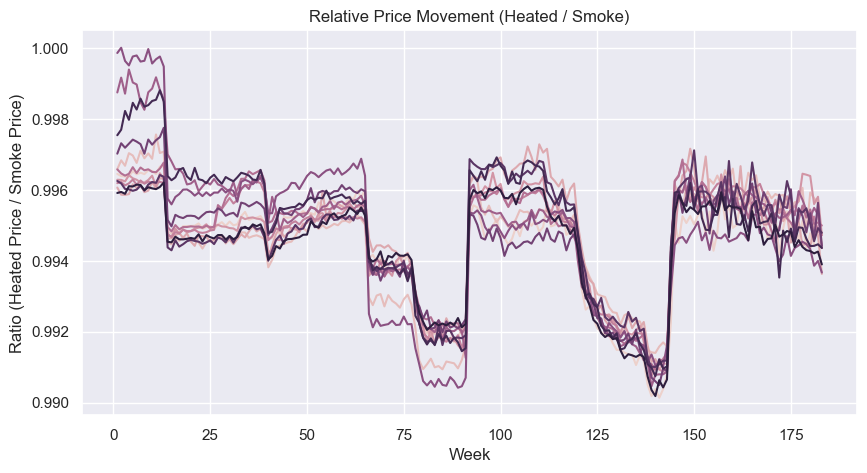

In [17]:
# Calculate the Relative Price Ratio
df_ratio = df_clean.copy()
df_ratio['Price_Ratio'] = df_ratio['Price_Heated'] / df_ratio['Price_Smoke']

# Check how much this ratio actually changes
print("--- Price Ratio (Heated / Smoke) Statistics ---")
print(df_ratio['Price_Ratio'].describe())

# Visual check: Is it a flat line?
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_ratio, x='W', y='Price_Ratio', hue='region', alpha=1, legend=False)
plt.title("Relative Price Movement (Heated / Smoke)")
plt.ylabel("Ratio (Heated Price / Smoke Price)")
plt.xlabel("Week")
plt.show()

Long to Wide format of indices data

In [18]:

# 1. Define the specific columns you want to keep
# Note: We include 'type' here to filter, but we will drop it before merging
cols_to_keep = ['W', 'region', 'type', 'Laspeyres', 'Paasche', 'Fisher', 'Tornqvist']

# 2. Split the data into two dataframes (Smoke and Heat)
# We filter by type and select only the desired columns
df_smoke = indices.loc[indices['type'] == 1, cols_to_keep].copy()
df_heat = indices.loc[indices['type'] == 2, cols_to_keep].copy()

# 3. Rename the value columns
# We do NOT rename 'W' or 'region' because those are our merge keys.
# We drop 'type' since the column suffixes (_Smoke/_Heat) now tell us the type.
value_cols = ['Laspeyres', 'Paasche', 'Fisher', 'Tornqvist']

suffix_smoke = {col: f"{col}_Smoke" for col in value_cols}
suffix_heat = {col: f"{col}_Heat" for col in value_cols}

df_smoke.rename(columns=suffix_smoke, inplace=True)
df_heat.rename(columns=suffix_heat, inplace=True)

# Drop the 'type' column now as it's no longer needed
df_smoke.drop(columns=['type'], inplace=True)
df_heat.drop(columns=['type'], inplace=True)

# 4. Merge them back together
# We merge on Week ('W') and Region ('region') to get one row per market-week
df_wide = pd.merge(df_smoke, df_heat, on=['W', 'region'], how='inner')

# 5. Check the result
df_wide

,W,region,Laspeyres_Smoke,Paasche_Smoke,Fisher_Smoke,Tornqvist_Smoke,Laspeyres_Heat,Paasche_Heat,Fisher_Heat,Tornqvist_Heat
0,1,1,0.960471,0.960322,0.960397,0.979987,0.953496,0.953712,0.953604,0.976514
1,2,1,0.960391,0.960663,0.960527,0.980156,0.953489,0.953921,0.953705,0.976621
2,3,1,0.960386,0.960516,0.960451,0.980081,0.953473,0.953754,0.953614,0.976536
3,4,1,0.960410,0.960551,0.960480,0.980097,0.953476,0.953789,0.953632,0.976553
4,5,1,0.960440,0.960239,0.960339,0.979947,0.953486,0.953782,0.953634,0.976550
...,...,...,...,...,...,...,...,...,...,...
2374,179,13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2375,180,13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2376,181,13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2377,182,13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
df_wide

df_wide.to_csv('price_indices_FINAL.csv', index=False) #region-week level
